In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split as tts
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [234]:
faces = fetch_lfw_people(min_faces_per_person=70, resize = 0.5)

In [237]:
dir(faces)

['DESCR', 'data', 'images', 'target', 'target_names']

# Assessing Dataset

### sample images

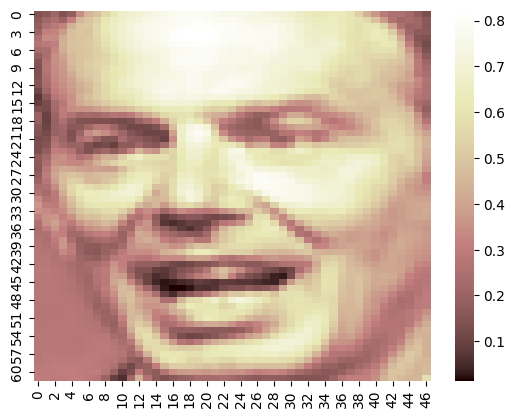

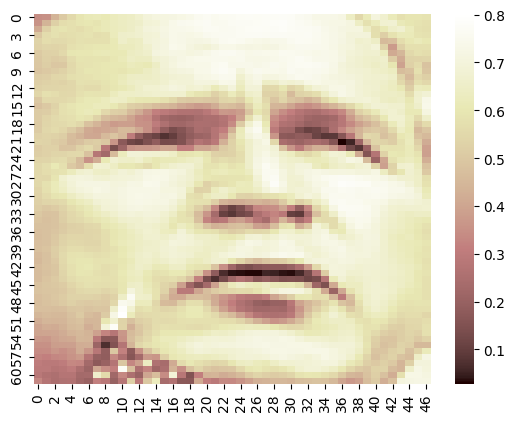

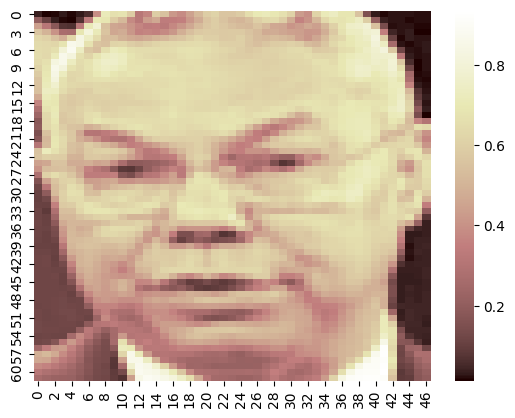

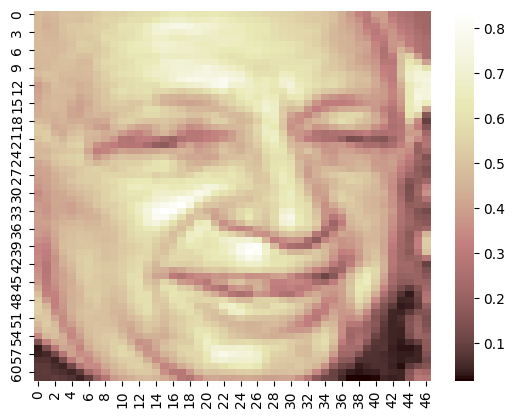

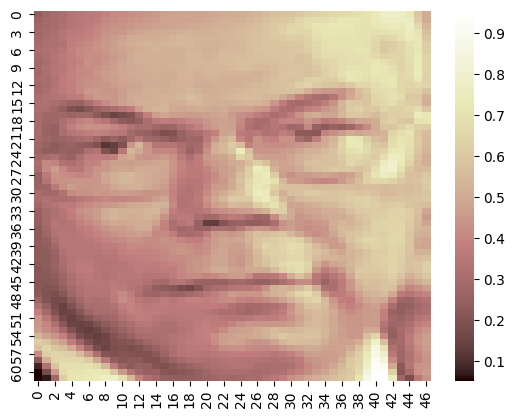

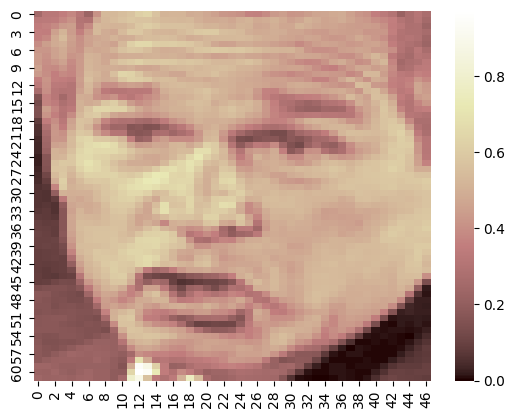

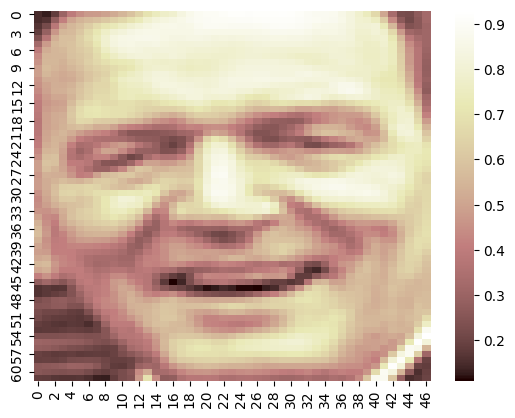

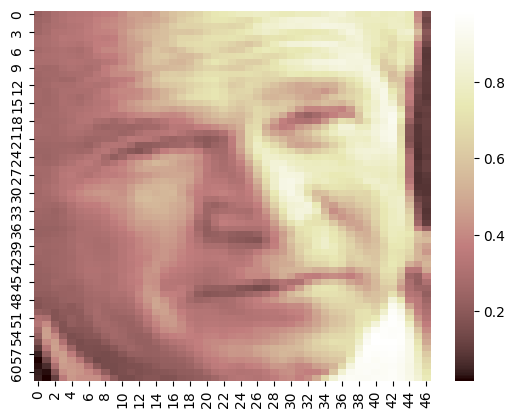

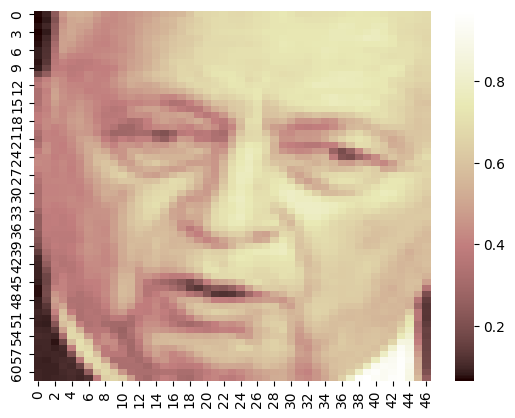

In [238]:
for i in range(1, 10):
    sns.heatmap(faces.images[i], cmap = 'pink')
    plt.show()

In [239]:
faces.target_names

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair'], dtype='<U17')

# The dataset contains pictures of the following people

 1.)`Ariel Sharon`
 
 2.)`Colin Powell`
 
 3.)`Donald Rumsfeld`
 
 4.)`George W Bush`

 5.)`Gerhard Schroeder`
 
 6.)`Hugo Chavez`
 
 7.)`Junichiro Koizumi`
 
 8.)`Tony Blair`


In [240]:
faces.images[0].shape

(62, 47)

#### each images is of shape 62 x 47 pixels 

#### The data however is a flattened one dimensional array of the images.

In [241]:
X = faces.data

In [242]:
y = faces.target

#### --> Splitting dataset for training and testing

In [243]:
X_train, X_test, y_train, y_test = tts(X, y, test_size = 0.2)

#### --> Training Data using SVM

In [244]:
model = SVC()

In [245]:
model.fit(X_train, y_train)

SVC()

In [246]:
model.score(X_test, y_test)

0.7403100775193798

In [247]:
y_pred = model.predict(X_test)

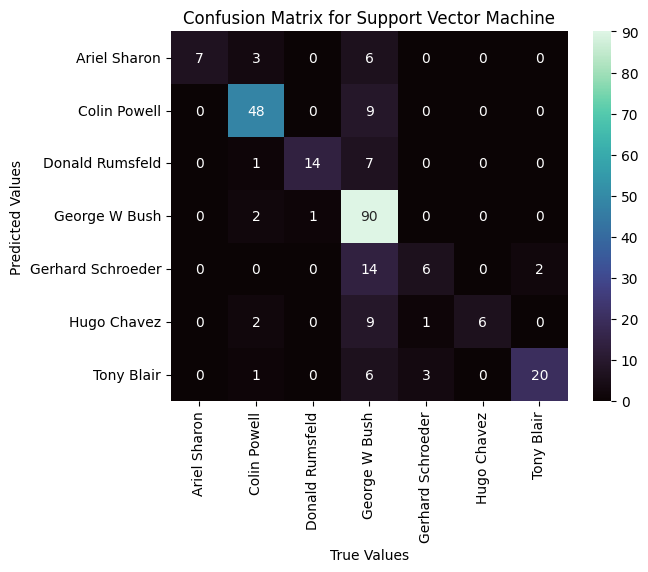

In [248]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            cmap = 'mako',
            annot = True,
            xticklabels = faces.target_names,
            yticklabels = faces.target_names)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Confusion Matrix for Support Vector Machine')
plt.show()

#### --> Training Data using Random Forests

In [249]:
model2 = RandomForestClassifier()

In [250]:
model2.fit(X_train, y_train)

RandomForestClassifier()

In [251]:
model2.score(X_test, y_test)

0.6007751937984496

In [252]:
y_pred2 = model2.predict(X_test)

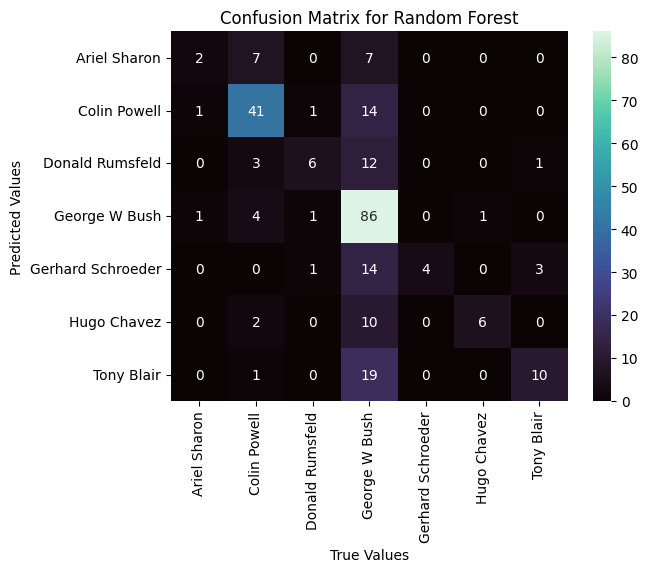

In [253]:
sns.heatmap(confusion_matrix(y_test, y_pred2),
            cmap = 'mako',
            annot = True,
            xticklabels = faces.target_names,
            yticklabels = faces.target_names)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Confusion Matrix for Random Forest')
plt.show()

#### --> Training Data using Logisctic Regression

In [254]:
model3 = LogisticRegression(solver = 'lbfgs', max_iter = 1000)

In [255]:
model3.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [256]:
model3.score(X_test, y_test)

0.8255813953488372

In [257]:
y_pred3 = model3.predict(X_test)

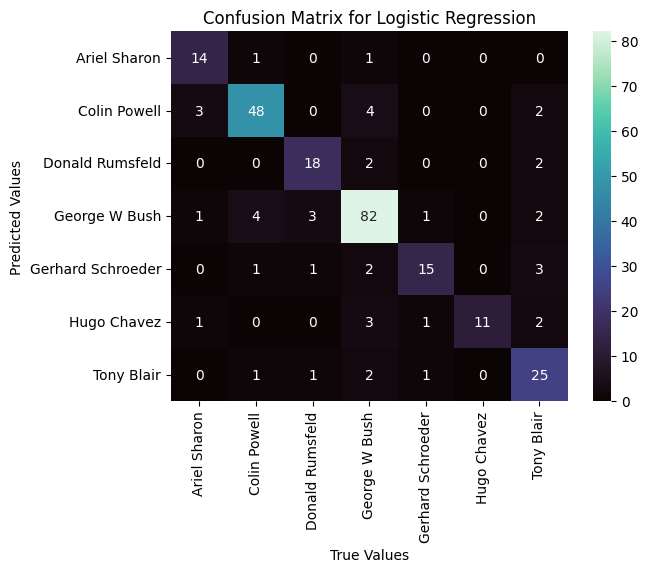

In [258]:
sns.heatmap(confusion_matrix(y_test, y_pred3),
            cmap = 'mako',
            annot = True,
            xticklabels = faces.target_names,
            yticklabels = faces.target_names)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

#### --> Training Data using Decision Tree

In [259]:
model4 = tree.DecisionTreeClassifier()

In [260]:
model4.fit(X_train, y_train)

DecisionTreeClassifier()

In [261]:
model4.score(X_test, y_test)

0.4573643410852713

In [262]:
y_pred4 = model4.predict(X_test)

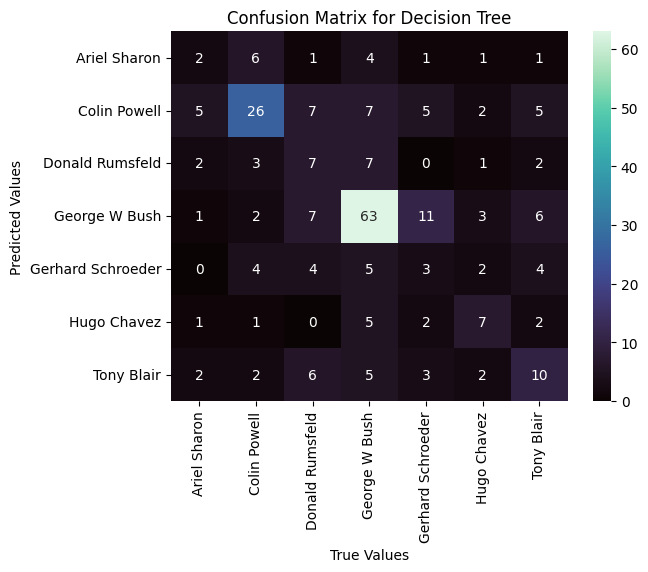

In [263]:
sns.heatmap(confusion_matrix(y_test, y_pred4),
            cmap = 'mako',
            annot = True,
            xticklabels = faces.target_names,
            yticklabels = faces.target_names)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

#### --> Training Data using nueral network

In [264]:
model5 = MLPClassifier(max_iter = 700, hidden_layer_sizes = (1000,))

In [265]:
model5.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(1000,), max_iter=700)

In [266]:
model5.score(X_test, y_test)

0.8294573643410853

In [267]:
y_pred5 = model5.predict(X_test)

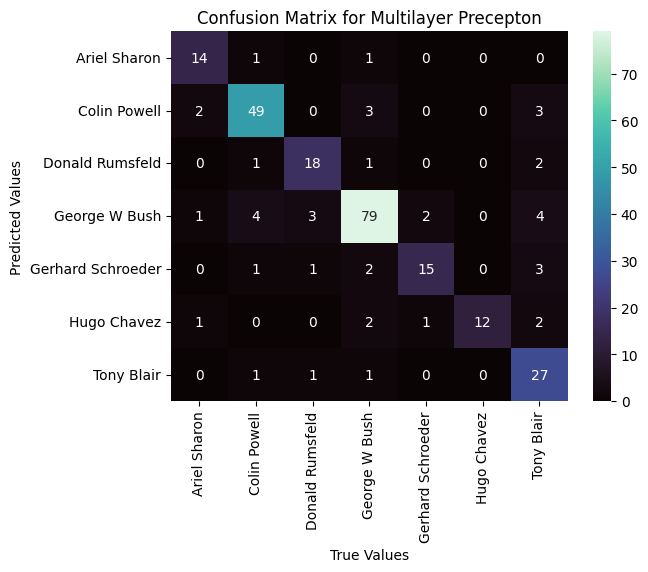

In [268]:
sns.heatmap(confusion_matrix(y_test, y_pred5),
            cmap = 'mako',
            annot = True,
            xticklabels = faces.target_names,
            yticklabels = faces.target_names)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Confusion Matrix for Multilayer Precepton')
plt.show()

In [269]:
for i in range(len(faces.target_names)):
    print('name:', faces.target_names[i], 'num:', (faces.target == i).sum())

name: Ariel Sharon num: 77
name: Colin Powell num: 236
name: Donald Rumsfeld num: 121
name: George W Bush num: 530
name: Gerhard Schroeder num: 109
name: Hugo Chavez num: 71
name: Tony Blair num: 144


In [270]:
faces.data.shape

(1288, 2914)

#### The reason for relatively low accuracy (by no means bad) is that the dataset is somewhat biased, as you can see above George W. Bush has more images than any other person in the dataset. Therefore it effects the overall accuracy of these models. The accuracy of Multi-Layer precepton and logistic Regression models are seemingly higher than other Algorithms. However that does not mean that these algorithms are inferior. It simply means that either these datasets are more prone to biasness or it could also mean the type of the data isn't suitable for such models. 